# 实验六：Transformer 与手动实现 MicroGPT

欢迎来到实验六。在本实验中，你将**从零手写一个完整的 GPT-2 风格语言模型**，并使用纯 Python（不依赖任何深度学习框架）完成自动微分、模型定义、训练与推理全流程。

实验的核心代码来自 `microgpt.py`（作者：Andrej Karpathy），该文件仅依赖 Python 标准库，用不足 200 行代码实现了一个可运行的 Mini-GPT，是学习 Transformer 底层机制的绝佳材料。

---

**本实验的主要学习目标：**

1. 理解并实现**自动微分**（Autograd）引擎的核心原理（计算图 + 反向传播）。
2. 理解 Transformer 的核心组件：**RMSNorm**、**多头自注意力（Multi-Head Self-Attention）**、**前馈网络（MLP）**。
3. 理解 GPT 的**训练流程**：数据准备 → 前向传播 → 交叉熵损失 → 反向传播 → Adam 优化。
4. 理解 GPT 的**推理流程**（自回归采样）。

---

**约定：** 本 Notebook 中凡是出现 `### START CODE HERE ###` 与 `### END CODE HERE ###` 之间的区域，均需要你手动补全代码，其余代码已由实验框架提供，**请勿修改**。

---

> 实验环境：Python 3.7+，无需额外安装 PyTorch，所有实现仅使用 `math`、`random`、`os` 标准库。


## 第一部分：数据准备与分词器（Tokenizer）

### 1.1 读取数据集

我们的任务是训练一个能够生成人名（English names）的字符级语言模型。训练数据为 `input.txt`，每行包含一个名字，例如：
```
emma
olivia
ava
...
```

### 1.2 字符级 Tokenizer

**Tokenizer（分词器）** 的作用是在字符串与整数序列（token id）之间做双向映射：

- **编码（encode）**：`"emma"` → `[4, 12, 12, 0]`
- **解码（decode）**：`[4, 12, 12, 0]` → `"emma"`

对于字符级模型，每个**唯一字符**对应一个 token id（id = 0, 1, …, V-1）。

此外，我们还引入一个特殊的 **BOS（Beginning of Sequence）** token，用于：
- 训练时：作为每条序列的开头和结尾标志，帮助模型学习「在何处开始」与「在何处停止」生成。
- 推理时：以 BOS token 作为起始输入，触发模型生成。

`BOS` 的 token id 被设为 `vocab_size - 1`（所有普通字符 id 之后）。

**词表大小（vocab_size）** = 唯一字符数 + 1（BOS）。


In [1]:
import os
import math
import random

random.seed(42)

# ---------- 读取数据 ----------
if not os.path.exists('input.txt'):
    import urllib.request
    names_url = 'https://raw.githubusercontent.com/karpathy/makemore/988aa59/names.txt'
    urllib.request.urlretrieve(names_url, 'input.txt')

with open('input.txt') as f:
    docs = [line.strip() for line in f if line.strip()]
random.shuffle(docs)
print(f"文档（名字）总数: {len(docs)}")
print(f"前 10 个名字样例: {docs[:10]}")


文档（名字）总数: 32033
前 10 个名字样例: ['yuheng', 'diondre', 'xavien', 'jori', 'juanluis', 'erandi', 'phia', 'samatha', 'phoenix', 'emmelynn']


### 练习 1：构建字符级 Tokenizer

**任务：**

1. 从所有文档中收集**唯一字符集合** `uchars`，并排序（`sorted(set(...))`）。
2. 设定 `BOS = len(uchars)`（BOS token 的 id 紧接在普通字符之后）。
3. 设定 `vocab_size = len(uchars) + 1`（+ 1 是为了给 BOS 留一个 id）。

**提示：**
- 可以用 `''.join(docs)` 将所有名字拼接成一个大字符串，再用 `set(...)` 提取唯一字符。
- `sorted(...)` 保证字符顺序是确定的（不依赖集合的随机顺序）。


In [2]:
### START CODE HERE ###
# 1. 收集所有文档中的唯一字符，并按字母序排列，得到 uchars（list[str]）

# 2. BOS token id = 唯一字符数

# 3. vocab_size = 唯一字符数 + 1
### END CODE HERE ###

print(f"唯一字符: {uchars}")
print(f"BOS token id: {BOS}")
print(f"词表大小 (vocab_size): {vocab_size}")


唯一字符: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
BOS token id: 26
词表大小 (vocab_size): 27


### 测试练习 1

运行以下单元格，若输出与预期一致，则说明你的实现正确。

**预期输出：**
```
✅ uchars 长度正确: 26
✅ BOS id 正确: 26
✅ vocab_size 正确: 27
✅ 全部字符为小写英文字母
```


In [3]:
# ===== 测试单元格（无需修改）=====
def test_tokenizer():
    assert len(uchars) == 26, f"❌ uchars 长度应为 26，实际为 {len(uchars)}"
    print(f"✅ uchars 长度正确: {len(uchars)}")
    assert BOS == 26, f"❌ BOS 应为 26，实际为 {BOS}"
    print(f"✅ BOS id 正确: {BOS}")
    assert vocab_size == 27, f"❌ vocab_size 应为 27，实际为 {vocab_size}"
    print(f"✅ vocab_size 正确: {vocab_size}")
    assert all(c.islower() for c in uchars), "❌ uchars 中存在非小写字母字符"
    print("✅ 全部字符为小写英文字母")
    # 简单编解码测试
    name = "emma"
    token_ids = [uchars.index(ch) for ch in name]
    decoded = ''.join(uchars[t] for t in token_ids)
    assert decoded == name, f"❌ 编解码不一致: {decoded} != {name}"
    print(f"✅ 编解码测试通过: '{name}' -> {token_ids} -> '{decoded}'")

test_tokenizer()


✅ uchars 长度正确: 26
✅ BOS id 正确: 26
✅ vocab_size 正确: 27
✅ 全部字符为小写英文字母
✅ 编解码测试通过: 'emma' -> [4, 12, 12, 0] -> 'emma'


---

## 第二部分：自动微分引擎（Autograd）

### 2.1 为什么需要自动微分？

训练神经网络的关键步骤是**反向传播（Backpropagation）**：根据损失函数对每个参数求偏导数（梯度），然后用梯度下降更新参数。

手动对复杂网络求导极为繁琐且容易出错。**自动微分（Autograd）** 系统通过记录运算的计算图，自动应用链式法则，无需手动推导。

### 2.2 标量值节点 `Value`

我们用一个 `Value` 类来表示计算图中的每个**标量节点**：

```
Value(data, children, local_grads)
  ├─ data        : 前向传播时计算得到的标量值
  ├─ grad        : 反向传播时累积的梯度 ∂L/∂self
  ├─ _children   : 生成本节点的子节点（输入）列表
  └─ _local_grads: 本节点对各子节点的局部偏导数
```

**链式法则（Chain Rule）：**

$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial x}$$

反向传播时，对每个节点 $y$，其梯度 `y.grad`（即 $\partial L / \partial y$）乘以局部导数 $\partial y / \partial x$ 即可累加到子节点 $x$ 的梯度上。

### 2.3 各运算的局部导数

| 运算 | 公式 | $\partial \text{out} / \partial a$ | $\partial \text{out} / \partial b$（如适用）|
|------|------|---------------------------------------|-----------------------------------------------|
| 加法 $a + b$ | $\text{out} = a + b$ | 1 | 1 |
| 乘法 $a \times b$ | $\text{out} = a \cdot b$ | $b$ | $a$ |
| 幂次 $a^k$ | $\text{out} = a^k$ | $k \cdot a^{k-1}$ | — |
| 对数 $\ln a$ | $\text{out} = \ln a$ | $1/a$ | — |
| 指数 $e^a$ | $\text{out} = e^a$ | $e^a$ | — |
| ReLU | $\text{out} = \max(0, a)$ | $\mathbb{1}[a > 0]$ | — |

### 2.4 拓扑排序与反向传播

`backward()` 方法通过**深度优先后序遍历（DFS 拓扑排序）**确定各节点的计算顺序，再从最终输出节点开始，按**逆拓扑序**依次传播梯度：

$$\text{child.grad} \mathrel{{+}{=}} \text{local\_grad} \times \text{node.grad}$$


### 练习 2：实现 `Value.__mul__` 与 `Value.__pow__`

`Value` 类中已实现了加法（`__add__`）。请参照其实现，补全**乘法**（`__mul__`）和**幂次**（`__pow__`）运算。

**提示：**

对于乘法 $\text{out} = a \times b$：
- `out.data = a.data * b.data`
- `children = (self, other)`
- 对 `self` 的局部导数为 `other.data`，对 `other` 的局部导数为 `self.data`
- 即 `local_grads = (other.data, self.data)`

对于幂次 $\text{out} = a^k$（`other` 是 Python 数值，不是 `Value` 对象）：
- `out.data = self.data ** other`
- `children = (self,)`
- 局部导数为 $k \cdot a^{k-1}$，即 `local_grads = (other * self.data**(other-1),)`


In [4]:
class Value:
    __slots__ = ('data', 'grad', '_children', '_local_grads')

    def __init__(self, data, children=(), local_grads=()):
        self.data = data
        self.grad = 0
        self._children = children
        self._local_grads = local_grads

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data + other.data, (self, other), (1, 1))

    ### START CODE HERE ###
    # TODO 1：在 Value 类中定义 def __mul__(self, other):。
    # TODO 2：乘法需要返回新的 Value，并记录两个输入节点的局部导数。
    # TODO 3：在 Value 类中定义 def __pow__(self, other):，其中 other 是普通数值。
        # 将 other 转成 Value（如果它不是 Value 的话）
        # out.data = self.data * other.data
        # local_grads: 对 self 的偏导 = other.data，对 other 的偏导 = self.data

        # other 是普通 Python 数值（int 或 float），不是 Value
        # out.data = self.data ** other
        # local_grad 对 self 的偏导 = other * self.data^(other-1)
    ### END CODE HERE ###

    def log(self):  return Value(math.log(self.data),  (self,), (1/self.data,))
    def exp(self):  return Value(math.exp(self.data),  (self,), (math.exp(self.data),))
    def relu(self): return Value(max(0, self.data),     (self,), (float(self.data > 0),))

    def __neg__(self):          return self * -1
    def __radd__(self, other):  return self + other
    def __sub__(self, other):   return self + (-other)
    def __rsub__(self, other):  return other + (-self)
    def __rmul__(self, other):  return self * other
    def __truediv__(self, other):  return self * other**-1
    def __rtruediv__(self, other): return other * self**-1

    def backward(self):
        topo, visited = [], set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._children:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1
        for v in reversed(topo):
            for child, local_grad in zip(v._children, v._local_grads):
                child.grad += local_grad * v.grad

print("Value 类定义完成。")


Value 类定义完成。


### 测试练习 2：自动微分正确性验证

我们用一个简单的表达式 $L = (a \times b + c)^2$ 来验证自动微分是否正确。

对于 $a=2, b=3, c=1$：
$$L = (2 \times 3 + 1)^2 = 49$$
$$\frac{\partial L}{\partial a} = 2(ab+c) \cdot b = 2 \times 7 \times 3 = 42$$
$$\frac{\partial L}{\partial b} = 2(ab+c) \cdot a = 2 \times 7 \times 2 = 28$$
$$\frac{\partial L}{\partial c} = 2(ab+c) \cdot 1 = 14$$

**预期输出：**
```
✅ L.data = 49.0 正确
✅ a.grad = 42.0 正确
✅ b.grad = 28.0 正确
✅ c.grad = 14.0 正确
```


In [5]:
# ===== 测试单元格（无需修改）=====
def test_autograd():
    a = Value(2.0)
    b = Value(3.0)
    c = Value(1.0)
    L = (a * b + c) ** 2
    L.backward()
    assert abs(L.data - 49.0) < 1e-9,  f"❌ L.data 应为 49.0，实际为 {L.data}"
    print(f"✅ L.data = {L.data} 正确")
    assert abs(a.grad - 42.0) < 1e-9,  f"❌ a.grad 应为 42.0，实际为 {a.grad}"
    print(f"✅ a.grad = {a.grad} 正确")
    assert abs(b.grad - 28.0) < 1e-9,  f"❌ b.grad 应为 28.0，实际为 {b.grad}"
    print(f"✅ b.grad = {b.grad} 正确")
    assert abs(c.grad - 14.0) < 1e-9,  f"❌ c.grad 应为 14.0，实际为 {c.grad}"
    print(f"✅ c.grad = {c.grad} 正确")

test_autograd()


✅ L.data = 49.0 正确
✅ a.grad = 42.0 正确
✅ b.grad = 28.0 正确
✅ c.grad = 14.0 正确


---

## 第三部分：模型超参数与参数初始化

### 3.1 GPT-2 超参数

本实验采用一个**轻量版 GPT-2** 结构，参数量极小（便于纯 Python 运行）：

| 超参数 | 符号 | 本实验取值 | 含义 |
|--------|------|-----------|------|
| 层数   | `n_layer` | 1 | Transformer 层数（深度）|
| 嵌入维度 | `n_embd` | 16 | 每个 token 的向量表示维度（宽度）|
| 最大序列长度 | `block_size` | 16 | 注意力窗口最大长度 |
| 注意力头数 | `n_head` | 4 | 多头注意力的头数 |
| 头维度 | `head_dim` | `n_embd // n_head = 4` | 每个注意力头的维度 |

### 3.2 参数命名与存储

所有可训练参数存储在字典 `state_dict` 中，键名含义如下：

- `wte`：Token Embedding 矩阵，形状 `(vocab_size, n_embd)`
- `wpe`：Position Embedding 矩阵，形状 `(block_size, n_embd)`
- `lm_head`：语言模型输出头，形状 `(vocab_size, n_embd)`
- `layer{i}.attn_wq/wk/wv/wo`：第 `i` 层的注意力 Q/K/V/O 权重矩阵，各形状 `(n_embd, n_embd)`
- `layer{i}.mlp_fc1`：MLP 第一层，形状 `(4*n_embd, n_embd)`（升维）
- `layer{i}.mlp_fc2`：MLP 第二层，形状 `(n_embd, 4*n_embd)`（降维）

### 3.3 参数初始化

所有权重矩阵从**均值为 0、标准差为 0.08 的高斯分布**中随机采样初始化。


In [6]:
# ─── 超参数 ───
n_layer     = 1
n_embd      = 16
block_size  = 16
n_head      = 4
head_dim    = n_embd // n_head   # = 4

print(f"n_layer={n_layer}, n_embd={n_embd}, block_size={block_size}, "
      f"n_head={n_head}, head_dim={head_dim}")

# ─── 辅助函数：生成随机权重矩阵 ───
# matrix(nout, nin) 返回一个 nout×nin 的 list[list[Value]]，
# 每个元素从 N(0, std) 中采样。
matrix = lambda nout, nin, std=0.08: [
    [Value(random.gauss(0, std)) for _ in range(nin)]
    for _ in range(nout)
]

# ─── 构建 state_dict ───
state_dict = {
    'wte':     matrix(vocab_size, n_embd),   # token embeddings
    'wpe':     matrix(block_size, n_embd),   # position embeddings
    'lm_head': matrix(vocab_size, n_embd),   # output projection
}
for i in range(n_layer):
    state_dict[f'layer{i}.attn_wq'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wk'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wv'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wo'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc1'] = matrix(4 * n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc2'] = matrix(n_embd, 4 * n_embd)

params = [p for mat in state_dict.values() for row in mat for p in row]
print(f"可训练参数总数: {len(params)}")


n_layer=1, n_embd=16, block_size=16, n_head=4, head_dim=4
可训练参数总数: 4192


---

## 第四部分：模型组件实现

### 4.1 线性变换（Linear）

线性变换 $\boldsymbol{y} = \boldsymbol{W}\boldsymbol{x}$（无偏置）：

$$y_i = \sum_{j} W_{ij} x_j, \quad i = 0, 1, \ldots, d_{out}-1$$

其中 $\boldsymbol{W}$ 是 `nout × nin` 的权重矩阵（用 `list[list[Value]]` 表示），$\boldsymbol{x}$ 是长度为 `nin` 的向量（用 `list[Value]` 表示）。

输出是长度为 `nout` 的向量：每个输出 $y_i$ 是 $\boldsymbol{W}$ 第 $i$ 行（`w[i]`）与输入 $\boldsymbol{x}$ 的点积（`sum(wi * xi for wi, xi in zip(...))`）。


### 练习 3：实现 `linear` 函数

**函数签名：** `linear(x, w) -> list[Value]`

**参数：**
- `x`：输入向量，`list[Value]`，长度为 `nin`
- `w`：权重矩阵，`list[list[Value]]`，形状为 `nout × nin`

**返回：** 长度为 `nout` 的 `list[Value]`，第 `i` 个元素为 $\sum_j w[i][j] \cdot x[j]$

**提示：**
- 外层用列表推导 `[... for wo in w]` 遍历每一行 `wo`
- 内层用 `sum(wi * xi for wi, xi in zip(wo, x))` 计算点积


In [7]:
### START CODE HERE ###
# TODO：定义 linear(x, w) 函数，并返回每一行权重与输入向量的点积。
    # x: list[Value], 长度 nin
    # w: list[list[Value]], 形状 nout × nin
    # 返回: list[Value], 长度 nout
    # 第 i 个输出 = sum(w[i][j] * x[j] for j in range(nin))
### END CODE HERE ###

print("linear 函数定义完成。")


linear 函数定义完成。


### 4.2 Softmax 函数

Softmax 将一组实数 logit 转换为概率分布：

$$\text{softmax}(z_i) = \frac{e^{z_i - \max(z)}}{\sum_j e^{z_j - \max(z)}}$$

减去 $\max(z)$（**数值稳定性技巧**）保证指数运算不会溢出，同时不改变 softmax 的输出值（分子分母同乘 $e^{-\max(z)}$）。


In [8]:
def softmax(logits):
    max_val = max(val.data for val in logits)   # 数值稳定：减去最大值
    exps = [(val - max_val).exp() for val in logits]
    total = sum(exps)
    return [e / total for e in exps]

print("softmax 函数定义完成。")


softmax 函数定义完成。


### 4.3 RMSNorm（均方根归一化）

**Layer Normalization** 的变体，去掉了均值对齐（mean subtraction），只做**均方根尺度缩放**：

$$\text{RMSNorm}(x_i) = \frac{x_i}{\sqrt{\text{MS}(x) + \epsilon}}$$

其中均方（Mean Square）为：
$$\text{MS}(x) = \frac{1}{d}\sum_{i=1}^d x_i^2$$

$\epsilon = 10^{-5}$ 防止除以零。

**GPT-2 原版使用 LayerNorm**，本实现简化为 RMSNorm（无可学习的 scale/shift 参数），便于手动实现。


### 练习 4：实现 `rmsnorm` 函数

**函数签名：** `rmsnorm(x) -> list[Value]`

**参数：**
- `x`：输入向量，`list[Value]`，长度为 `d`

**返回：** 归一化后的向量，长度同 `d`

**实现步骤：**
1. 计算均方 `ms = sum(xi * xi for xi in x) / len(x)`
2. 计算缩放因子 `scale = (ms + 1e-5) ** -0.5`（即 $1 / \sqrt{\text{MS}+\epsilon}$）
3. 返回 `[xi * scale for xi in x]`


In [9]:
### START CODE HERE ###
# TODO：定义 rmsnorm(x) 函数，依次计算均方、缩放因子和归一化向量。
    # 1. 计算均方: ms = (1/d) * sum(xi^2)
    # 2. 计算缩放因子: scale = (ms + 1e-5)^(-0.5)
    # 3. 返回归一化后的向量
### END CODE HERE ###

print("rmsnorm 函数定义完成。")


rmsnorm 函数定义完成。


### 测试练习 3 & 4：`linear` 与 `rmsnorm`

**预期输出：**
```
✅ linear 输出长度正确: 3
✅ linear 输出值正确 (y[0] ≈ 1.0, y[1] ≈ 0.0, y[2] ≈ -1.0)
✅ rmsnorm 输出长度正确: 3
✅ rmsnorm 输出 RMS 接近 1.0
```


In [10]:
# ===== 测试单元格（无需修改）=====
def test_linear_and_rmsnorm():
    # --- 测试 linear ---
    # W = [[1,0,0],[0,1,0],[0,0,1]] (单位矩阵), x = [1,0,-1]
    # 期望输出 y = [1, 0, -1]
    W = [[Value(1), Value(0), Value(0)],
         [Value(0), Value(1), Value(0)],
         [Value(0), Value(0), Value(1)]]
    x_in = [Value(1.0), Value(0.0), Value(-1.0)]
    y_out = linear(x_in, W)
    assert len(y_out) == 3, f"❌ linear 输出长度应为 3，实际为 {len(y_out)}"
    print(f"✅ linear 输出长度正确: {len(y_out)}")
    expected = [1.0, 0.0, -1.0]
    for i, (got, exp) in enumerate(zip(y_out, expected)):
        assert abs(got.data - exp) < 1e-9, f"❌ y[{i}] 应为 {exp}，实际为 {got.data}"
    print(f"✅ linear 输出值正确 (y[0]≈1.0, y[1]≈0.0, y[2]≈-1.0)")

    # --- 测试 rmsnorm ---
    x_in2 = [Value(3.0), Value(4.0), Value(0.0)]
    y_norm = rmsnorm(x_in2)
    assert len(y_norm) == 3, f"❌ rmsnorm 输出长度应为 3，实际为 {len(y_norm)}"
    print(f"✅ rmsnorm 输出长度正确: {len(y_norm)}")
    rms_out = (sum(v.data**2 for v in y_norm) / len(y_norm)) ** 0.5
    assert abs(rms_out - 1.0) < 1e-3, f"❌ rmsnorm 后 RMS 应接近 1.0，实际为 {rms_out:.6f}"
    print(f"✅ rmsnorm 输出 RMS 接近 1.0 (实际: {rms_out:.6f})")

test_linear_and_rmsnorm()


✅ linear 输出长度正确: 3
✅ linear 输出值正确 (y[0]≈1.0, y[1]≈0.0, y[2]≈-1.0)
✅ rmsnorm 输出长度正确: 3
✅ rmsnorm 输出 RMS 接近 1.0 (实际: 0.999999)


---

## 第五部分：GPT 模型前向传播

### 5.1 多头自注意力（Multi-Head Self-Attention）

自注意力机制是 Transformer 的核心，让模型在预测第 $t$ 步输出时能够**关注序列中所有已生成的 token**。

#### 单头注意力

对于单头注意力，输入向量 $\boldsymbol{x}$ 经过三个线性变换得到 Query、Key、Value：

$$\boldsymbol{q} = \boldsymbol{W}_Q \boldsymbol{x}, \quad \boldsymbol{k} = \boldsymbol{W}_K \boldsymbol{x}, \quad \boldsymbol{v} = \boldsymbol{W}_V \boldsymbol{x}$$

注意力得分（attn logit）为 Query 与各历史 Key 的点积，缩放后做 softmax：

$$\alpha_t = \text{softmax}\left(\frac{\boldsymbol{q} \cdot \boldsymbol{k}_t}{\sqrt{d_k}}\right)$$

输出为 Value 的加权求和：

$$\boldsymbol{h} = \sum_t \alpha_t \boldsymbol{v}_t$$

#### 多头注意力

将 `n_embd` 维的 Q/K/V 向量**切分为 `n_head` 段**，每段维度为 `head_dim`，各头**独立**计算注意力，最后**拼接**（concatenate）所有头的输出，再经过输出投影矩阵 $\boldsymbol{W}_O$：

$$\text{MultiHead}(\boldsymbol{x}) = \boldsymbol{W}_O \cdot \text{concat}(\boldsymbol{h}_1, \ldots, \boldsymbol{h}_{n_{head}})$$

#### KV Cache

在**推理**时，为了避免重复计算，每个 token 生成的 Key 和 Value 都缓存在 `keys[li]` 和 `values[li]` 列表中（`li` 为层索引）。训练时同样使用这个结构——每个位置的 token 只能"看到"自身及之前位置的 token（**因果掩码 / causal masking**）。

### 5.2 MLP 前馈网络

每个 Transformer 层的 MLP 块由两个线性层和 ReLU 激活组成（GPT-2 原版使用 GeLU，这里简化为 ReLU）：

$$\boldsymbol{h} = \boldsymbol{W}_2 \cdot \text{ReLU}(\boldsymbol{W}_1 \boldsymbol{x})$$

其中 $\boldsymbol{W}_1$ 将维度从 `n_embd` 升到 `4*n_embd`（扩展），$\boldsymbol{W}_2$ 再降回 `n_embd`（压缩）。

### 5.3 残差连接（Residual Connection）

每个 Attention 和 MLP 块都有残差连接：

$$\boldsymbol{x}_{out} = \boldsymbol{x}_{in} + \text{Block}(\boldsymbol{x}_{in})$$

这有助于缓解深层网络中的梯度消失问题，并提供恒等映射的捷径。


### 练习 5：实现 `gpt` 前向传播函数

这是本实验最核心的练习。请补全 `gpt` 函数中**多头自注意力**的计算部分。

**函数签名：** `gpt(token_id, pos_id, keys, values) -> list[Value]`

**参数：**
- `token_id`：当前 token 的整数 id
- `pos_id`：当前 token 在序列中的位置（0-indexed）
- `keys`：KV cache 中的 Key，`list[list[list[Value]]]`，`keys[li]` 存储第 `li` 层所有已处理 token 的 Key 向量
- `values`：KV cache 中的 Value，结构同 `keys`

**返回：** 长度为 `vocab_size` 的 `list[Value]`，表示下一个 token 的 logit 分数

**多头注意力计算步骤（需要补全的部分）：**

对于第 `h` 个头（`h = 0, 1, ..., n_head-1`）：

1. 计算该头的切片起始位置：`hs = h * head_dim`
2. 提取当前 token 的 Query 切片：`q_h = q[hs : hs+head_dim]`
3. 提取所有历史 token 的 Key 切片列表：`k_h = [ki[hs:hs+head_dim] for ki in keys[li]]`
4. 提取所有历史 token 的 Value 切片列表：`v_h = [vi[hs:hs+head_dim] for vi in values[li]]`
5. 计算注意力得分（scaled dot-product）：

$$\text{attn\_logit}_t = \frac{\sum_{j} q_h[j] \cdot k_h[t][j]}{\sqrt{\text{head\_dim}}}$$

6. 对注意力得分做 softmax 得到注意力权重 `attn_weights`
7. 加权求和得到该头的输出：

$$\text{head\_out}[j] = \sum_t \text{attn\_weights}[t] \cdot v_h[t][j]$$

8. 将所有头的输出拼接（`x_attn.extend(head_out)`）

**提示：**
- 步骤 5 中，对历史位置 `t` 的注意力得分为：`sum(q_h[j] * k_h[t][j] for j in range(head_dim)) / head_dim**0.5`
- 步骤 7 中，输出向量第 `j` 维为：`sum(attn_weights[t] * v_h[t][j] for t in range(len(v_h)))`


In [11]:
def gpt(token_id, pos_id, keys, values):
    # ── 1. Token + Position Embedding ──
    tok_emb = state_dict['wte'][token_id]      # 取第 token_id 行，得到 n_embd 维向量
    pos_emb = state_dict['wpe'][pos_id]        # 取第 pos_id 行，得到 n_embd 维向量
    x = [t + p for t, p in zip(tok_emb, pos_emb)]  # 相加
    x = rmsnorm(x)

    for li in range(n_layer):
        # ── 2. Multi-Head Self-Attention 块 ──
        x_residual = x
        x = rmsnorm(x)

        # 计算 Q, K, V（全维度，n_embd 维）
        q = linear(x, state_dict[f'layer{li}.attn_wq'])
        k = linear(x, state_dict[f'layer{li}.attn_wk'])
        v = linear(x, state_dict[f'layer{li}.attn_wv'])

        # 将当前 token 的 k, v 存入 KV cache
        keys[li].append(k)
        values[li].append(v)

        # 多头注意力计算
        x_attn = []

        ### START CODE HERE ###
        # TODO：补全 for h in range(n_head): 循环，逐头计算注意力并追加到 x_attn。
        # 提示：每个头需要依次得到 hs、q_h、k_h、v_h、attn_logits、attn_weights 和 head_out。
            # 1. 计算该头的切片起始下标

            # 2. 提取当前 token 的 Query 切片（长度 head_dim）

            # 3. 提取所有历史 token 的 Key 切片列表

            # 4. 提取所有历史 token 的 Value 切片列表

            # 5. 计算 scaled dot-product 注意力得分
            #    attn_logits[t] = (q_h · k_h[t]) / sqrt(head_dim)

            # 6. Softmax 得到注意力权重

            # 7. 用注意力权重对 Value 加权求和，得到当前头的输出（长度 head_dim）

            # 8. 拼接到 x_attn
        ### END CODE HERE ###

        # 输出投影
        x = linear(x_attn, state_dict[f'layer{li}.attn_wo'])
        # 残差连接
        x = [a + b for a, b in zip(x, x_residual)]

        # ── 3. MLP 块 ──
        x_residual = x
        x = rmsnorm(x)
        x = linear(x, state_dict[f'layer{li}.mlp_fc1'])  # 升维: n_embd -> 4*n_embd
        x = [xi.relu() for xi in x]                       # ReLU 激活
        x = linear(x, state_dict[f'layer{li}.mlp_fc2'])  # 降维: 4*n_embd -> n_embd
        # 残差连接
        x = [a + b for a, b in zip(x, x_residual)]

    # ── 4. 输出 logits ──
    logits = linear(x, state_dict['lm_head'])   # n_embd -> vocab_size
    return logits

print("gpt 函数定义完成。")


gpt 函数定义完成。


### 测试练习 5：GPT 前向传播

**预期输出：**
```
✅ logits 长度正确: 27
✅ KV cache 已更新: keys[0] 长度 = 1
✅ logits 均为 Value 对象
✅ logits 数值合理（未出现 NaN 或 Inf）
```


In [12]:
# ===== 测试单元格（无需修改）=====
def test_gpt_forward():
    test_keys   = [[] for _ in range(n_layer)]
    test_values = [[] for _ in range(n_layer)]
    logits = gpt(BOS, 0, test_keys, test_values)

    assert len(logits) == vocab_size,         f"❌ logits 长度应为 {vocab_size}，实际为 {len(logits)}"
    print(f"✅ logits 长度正确: {len(logits)}")

    assert len(test_keys[0]) == 1,         f"❌ KV cache 更新后 keys[0] 长度应为 1，实际为 {len(test_keys[0])}"
    print(f"✅ KV cache 已更新: keys[0] 长度 = {len(test_keys[0])}")

    assert all(isinstance(l, Value) for l in logits),         "❌ logits 中存在非 Value 对象"
    print("✅ logits 均为 Value 对象")

    for i, l in enumerate(logits):
        assert not (math.isnan(l.data) or math.isinf(l.data)),             f"❌ logits[{i}].data = {l.data} 出现 NaN 或 Inf"
    print("✅ logits 数值合理（未出现 NaN 或 Inf）")

test_gpt_forward()


✅ logits 长度正确: 27
✅ KV cache 已更新: keys[0] 长度 = 1
✅ logits 均为 Value 对象
✅ logits 数值合理（未出现 NaN 或 Inf）


---

## 第六部分：训练循环

### 6.1 交叉熵损失

语言模型的训练目标是**最大化真实下一个 token 出现的概率**，等价于**最小化交叉熵损失**：

$$\mathcal{L} = -\log P(\text{target\_id}) = -\log \text{softmax}(\text{logits})[\text{target\_id}]$$

对于一整条序列（长度为 $n$）：

$$\mathcal{L}_{\text{total}} = \frac{1}{n} \sum_{t=0}^{n-1} \mathcal{L}_t$$

### 6.2 Adam 优化器

**Adam（Adaptive Moment Estimation）** 优化器综合了 Momentum 和 RMSProp 的思想，对每个参数自适应调节有效学习率：

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t \quad \text{（一阶矩，动量项）}$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2 \quad \text{（二阶矩，自适应缩放项）}$$
$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t} \quad \text{（偏差修正）}$$
$$\theta_t = \theta_{t-1} - \alpha_t \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

其中 $\alpha_t$ 为当前学习率（本实验采用**线性学习率衰减**：$\alpha_t = \alpha_0 \cdot (1 - t/T)$）。

### 6.3 训练数据的准备

每个 training step 的数据格式：

1. 随机取一个名字（如 `"emma"`）
2. 在两端加上 BOS token：`tokens = [BOS, e_id, m_id, m_id, a_id, BOS]`
3. 输入序列（`token_id`）与目标序列（`target_id`）错位一格：

| 位置 | token_id | target_id |
|------|----------|-----------|
| 0    | BOS      | 'e'       |
| 1    | 'e'      | 'm'       |
| 2    | 'm'      | 'm'       |
| 3    | 'm'      | 'a'       |
| 4    | 'a'      | BOS       |

这样模型学习的是：**给定前缀，预测下一个字符**（含预测序列结束）。


### 练习 6：实现训练循环中的损失计算

在下面的训练循环中，每个 step 的损失已有大部分框架代码。请补全**将 logits 转为概率、计算负对数似然损失**的部分。

**提示：**
1. 调用 `softmax(logits)` 将 logits 转为概率分布 `probs`（`list[Value]`，长度 `vocab_size`）
2. 取出目标 token 的概率 `probs[target_id]`
3. 计算负对数似然：`loss_t = -probs[target_id].log()`

（`Value` 类的 `.log()` 方法已实现）


In [13]:
# ─── Adam 超参数 ───
learning_rate = 0.01
beta1, beta2, eps_adam = 0.85, 0.99, 1e-8
m_buf = [0.0] * len(params)   # 一阶矩缓冲
v_buf = [0.0] * len(params)   # 二阶矩缓冲

# ─── 训练循环 ───
num_steps = 1000
loss_history = []

for step in range(num_steps):
    # ── 取一条文档并 tokenize ──
    doc = docs[step % len(docs)]
    tokens = [BOS] + [uchars.index(ch) for ch in doc] + [BOS]
    n = min(block_size, len(tokens) - 1)

    # ── 前向传播 ──
    keys_cache   = [[] for _ in range(n_layer)]
    values_cache = [[] for _ in range(n_layer)]
    losses = []

    for pos_id in range(n):
        token_id  = tokens[pos_id]
        target_id = tokens[pos_id + 1]
        logits = gpt(token_id, pos_id, keys_cache, values_cache)

        ### START CODE HERE ###
        # 1. 将 logits 转为概率分布

        # 2. 计算当前位置的交叉熵损失（负对数似然）
        ### END CODE HERE ###

        losses.append(loss_t)

    # 序列平均损失
    loss = (1 / n) * sum(losses)

    # ── 反向传播 ──
    loss.backward()

    # ── Adam 参数更新 ──
    lr_t = learning_rate * (1 - step / num_steps)
    for i, p in enumerate(params):
        m_buf[i] = beta1 * m_buf[i] + (1 - beta1) * p.grad
        v_buf[i] = beta2 * v_buf[i] + (1 - beta2) * p.grad ** 2
        m_hat = m_buf[i] / (1 - beta1 ** (step + 1))
        v_hat = v_buf[i] / (1 - beta2 ** (step + 1))
        p.data -= lr_t * m_hat / (v_hat ** 0.5 + eps_adam)
        p.grad = 0   # 清零梯度

    loss_history.append(loss.data)
    if (step + 1) % 100 == 0:
        print(f"step {step+1:4d} / {num_steps:4d} | loss {loss.data:.4f}")

print("\n训练完成！")


step  100 / 1000 | loss 3.3669
step  200 / 1000 | loss 2.3097
step  300 / 1000 | loss 2.3178
step  400 / 1000 | loss 2.3428
step  500 / 1000 | loss 2.0645
step  600 / 1000 | loss 2.4851
step  700 / 1000 | loss 2.3357
step  800 / 1000 | loss 2.2632
step  900 / 1000 | loss 2.7785
step 1000 / 1000 | loss 2.6497

训练完成！


### 6.4 训练损失可视化

运行以下代码绘制训练损失曲线，观察模型是否收敛。


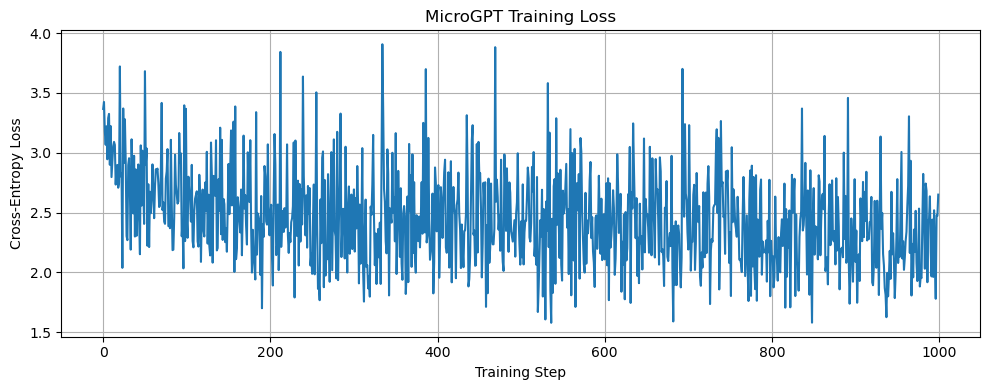

初始 loss: 3.3660
最终 loss: 2.6497


In [14]:
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 4))
    plt.plot(loss_history)
    plt.xlabel('Training Step')
    plt.ylabel('Cross-Entropy Loss')
    plt.title('MicroGPT Training Loss')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    print(f"初始 loss: {loss_history[0]:.4f}")
    print(f"最终 loss: {loss_history[-1]:.4f}")
except ImportError:
    print("matplotlib 未安装，跳过绘图。")
    print(f"初始 loss: {loss_history[0]:.4f}")
    print(f"最终 loss: {loss_history[-1]:.4f}")


---

## 第七部分：推理——自回归采样

### 7.1 自回归生成原理

语言模型的推理（生成）采用**自回归（autoregressive）**方式：

1. 以 **BOS token** 作为起始输入。
2. 将当前 token 输入模型，得到下一个 token 的概率分布。
3. 从概率分布中**采样**一个 token。
4. 将采样的 token 作为下一步的输入，回到步骤 2。
5. 当采样到 **BOS token**（序列结束标志）或达到最大长度 `block_size` 时停止。

### 7.2 温度（Temperature）采样

温度参数 $T \in (0, 1]$ 控制生成的多样性：

$$P(\text{token}_i) = \text{softmax}\left(\frac{\text{logits}}{T}\right)_i$$

- $T \to 0$（低温）：概率分布趋于集中，模型倾向于生成概率最高的 token（更保守、更确定）。
- $T = 1.0$（常温）：使用原始概率分布。
- $T > 1.0$（高温）：概率分布趋于平均，生成更随机（更"有创意"）。

### 7.3 加权随机采样

Python 的 `random.choices(population, weights, k=1)` 函数根据 `weights` 对 `population` 进行加权随机采样，非常适合从概率分布中采样 token。


### 练习 7：实现自回归推理

**任务：** 在下面的推理循环框架中，补全**从 logits 采样 token** 的部分。

**步骤：**
1. 将 logits 除以温度 $T$：`[l / temperature for l in logits]`（得到缩放后的 logits）
2. 对缩放后的 logits 做 softmax 得到概率分布 `probs`
3. 使用 `random.choices` 按权重采样下一个 token id：
   - `population = range(vocab_size)`
   - `weights = [p.data for p in probs]`（必须使用 `.data` 取出 Python 浮点数）

**提示：** `random.choices(range(vocab_size), weights=[p.data for p in probs])[0]` 返回采样到的 token id。


In [15]:
temperature = 0.5  # 温度参数：低温 -> 更保守；高温 -> 更多样

print("--- 推理：模型生成的名字 ---")
for sample_idx in range(20):
    keys_inf   = [[] for _ in range(n_layer)]
    values_inf = [[] for _ in range(n_layer)]

    token_id = BOS   # 以 BOS 作为第一个输入
    sample   = []

    for pos_id in range(block_size):
        logits = gpt(token_id, pos_id, keys_inf, values_inf)

        ### START CODE HERE ###
        # 1. 对 logits 应用温度缩放，并计算概率分布

        # 2. 按概率权重随机采样下一个 token id
        ### END CODE HERE ###

        # 如果采样到 BOS，表示序列结束，停止生成
        if token_id == BOS:
            break
        sample.append(uchars[token_id])

    print(f"样本 {sample_idx+1:2d}: {''.join(sample)}")


--- 推理：模型生成的名字 ---
样本  1: kamon
样本  2: ann
样本  3: karai
样本  4: jaire
样本  5: vialan
样本  6: karia
样本  7: yeran
样本  8: anna
样本  9: areli
样本 10: kaina
样本 11: konna
样本 12: keylen
样本 13: liole
样本 14: alerin
样本 15: earan
样本 16: lenne
样本 17: kana
样本 18: lara
样本 19: alela
样本 20: anton


### 测试练习 7：推理输出合法性

**预期输出：**
```
✅ 生成的名字均为非空字符串
✅ 所有字符均为合法词表字符（小写字母）
✅ 生成长度合理（1 ~ block_size 个字符）
```


In [16]:
# ===== 测试单元格（无需修改）=====
def test_inference():
    random.seed(0)
    for trial in range(5):
        keys_t   = [[] for _ in range(n_layer)]
        values_t = [[] for _ in range(n_layer)]
        token_id = BOS
        sample   = []
        for pos_id in range(block_size):
            logits = gpt(token_id, pos_id, keys_t, values_t)
            probs  = softmax([l / temperature for l in logits])
            token_id = random.choices(range(vocab_size),
                                      weights=[p.data for p in probs])[0]
            if token_id == BOS:
                break
            sample.append(uchars[token_id])
        name = ''.join(sample)
        assert len(name) >= 1, f"❌ 第 {trial+1} 个样本为空字符串"
        assert len(name) <= block_size,             f"❌ 第 {trial+1} 个样本长度超过 block_size ({len(name)} > {block_size})"
        assert all(c in uchars for c in name),             f"❌ 第 {trial+1} 个样本包含非法字符: '{name}'"
    print("✅ 生成的名字均为非空字符串")
    print("✅ 所有字符均为合法词表字符（小写字母）")
    print("✅ 生成长度合理（1 ~ block_size 个字符）")

test_inference()


✅ 生成的名字均为非空字符串
✅ 所有字符均为合法词表字符（小写字母）
✅ 生成长度合理（1 ~ block_size 个字符）


---

## 总结

恭喜你完成了实验六！在本实验中，你从零手写了一个完整的 GPT-2 风格语言模型，涵盖了以下核心模块：

| 模块 | 关键知识点 |
|------|-----------|
| 字符级 Tokenizer | 词表构建、BOS 特殊 token、编码与解码 |
| 自动微分引擎 | 计算图、链式法则、拓扑排序反向传播 |
| 线性变换 | 矩阵-向量乘法（无偏置） |
| RMSNorm | 均方根归一化、数值稳定性 |
| 多头自注意力 | Q/K/V 线性变换、Scaled Dot-Product Attention、多头拼接、KV Cache |
| MLP 前馈网络 | 升维-激活-降维、ReLU 激活 |
| 残差连接 | 梯度畅通、恒等映射捷径 |
| 交叉熵损失 | 负对数似然、语言建模目标 |
| Adam 优化器 | 一阶矩/二阶矩估计、偏差修正、自适应学习率 |
| 温度采样 | 自回归生成、采样多样性控制 |

**思考题（选做）：**

1. 增加 `n_layer`（如改为 2 层）或 `n_embd`（如改为 32），训练 loss 会如何变化？参数量会增加多少？
2. 如果将 RMSNorm 去掉，训练是否仍能正常收敛？为什么？
3. 尝试不同的温度 $T$（如 $T=0.1$ 和 $T=1.0$）进行推理，对比生成名字的差异。
4. 自注意力为什么要除以 $\sqrt{d_k}$（即 `head_dim**0.5`）？如果不除，会有什么问题？
